In [ ]:
import pandas as pd
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


df = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')

SUBSTASK 1: EDA & DATA PREPARATION
(1) Data Cleaning

In [65]:
df.isnull().sum()

Q1 = df['Total Spend'].quantile(0.25)
Q3 = df['Total Spend'].quantile(0.75)

IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outliers = df[(df['Total Spend'] < batas_bawah) | (df['Total Spend'] > batas_atas)]
print("outliers:", outliers)

outliers: Empty DataFrame
Columns: [Customer ID, Gender, Age, City, Membership Type, Total Spend, Items Purchased, Average Rating, Discount Applied, Days Since Last Purchase, Satisfaction Level]
Index: []


SUBSTASK 1: EDA & DATA PREPARATION
(2)Feature Engineering

In [66]:
df['Days Since Last Purchase'].replace(0, 1)

Purchase_Intensity = df['Total Spend'] / df['Days Since Last Purchase']
df['Purchase_Intensity'] = Purchase_Intensity


SUBSTASK 1: EDA & DATA PREPARATION
(3) Standardization

In [67]:
scaler = StandardScaler()
kolom_nomor = ['Age', 'Total Spend', 'Days Since Last Purchase', 'Purchase_Intensity', 'Items Purchased']
df[kolom_nomor] = scaler.fit_transform(df[kolom_nomor])
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase,Purchase_Intensity
count,350.000000,3.500000e+02,3.500000e+02,3.500000e+02,350.000000,3.500000e+02,3.500000e+02
mean,275.500000,2.023778e-16,1.126083e-16,8.390114e-17,4.019143,1.015061e-16,8.120488e-17
std,101.180532,1.001432e+00,1.001432e+00,1.001432e+00,0.580539,1.001432e+00,1.001432e+00
min,101.000000,-1.561939e+00,-1.202026e+00,-1.349384e+00,3.000000,-1.310468e+00,-8.827596e-01
25%,188.250000,-7.395565e-01,-9.497723e-01,-8.674609e-01,3.500000,-8.634271e-01,-7.701335e-01
50%,275.500000,-2.255677e-01,-1.941182e-01,-1.445768e-01,4.100000,-2.673729e-01,-3.535222e-01
75%,362.750000,6.996122e-01,8.718740e-01,5.783073e-01,4.500000,8.502287e-01,2.792339e-01
max,450.000000,1.933185e+00,1.866228e+00,2.024075e+00,4.900000,2.712898e+00,2.853735e+00


Subtask 2: UNSUPERVISED LEARNING
(1)KMeans

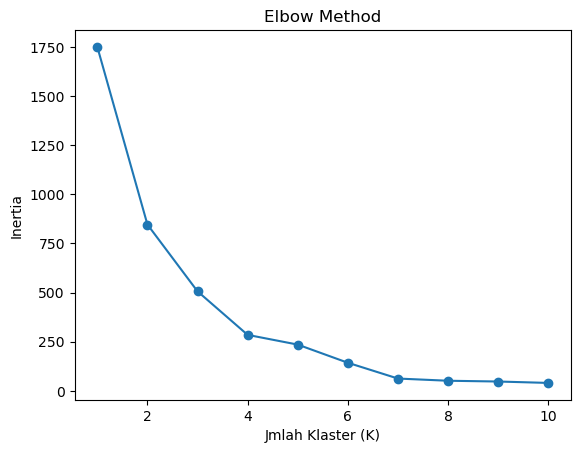

In [68]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df[kolom_nomor])
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jmlah Klaster (K)')
plt.ylabel('Inertia')
plt.show()

Cluster
1    118
0    116
2     58
3     58
Name: count, dtype: int64


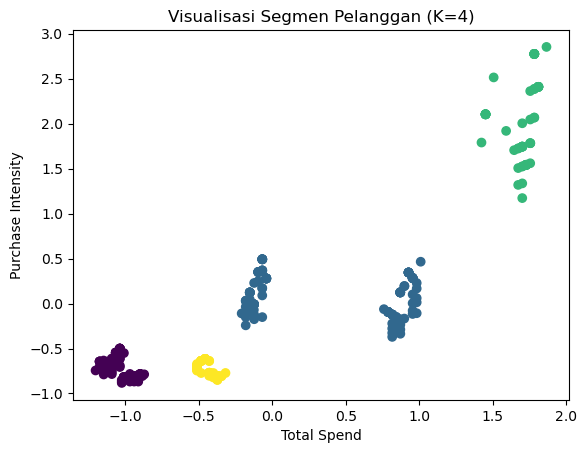

In [69]:
kmeans = KMeans(n_clusters=4, random_state=42)
hasil_cluster = kmeans.fit_predict(df[kolom_nomor])
df['Cluster'] = hasil_cluster
print(df['Cluster'].value_counts())

plt.scatter(df['Total Spend'], df['Purchase_Intensity'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Total Spend')
plt.ylabel('Purchase Intensity')
plt.title('Visualisasi Segmen Pelanggan (K=4)')
plt.show()

Subtask 2: UNSUPERVISED LEARNING
(2)DBScan

Cluster_DBSCAN
 0    59
 1    58
 2    58
 5    58
 3    57
 4    33
 6    24
-1     3
Name: count, dtype: int64


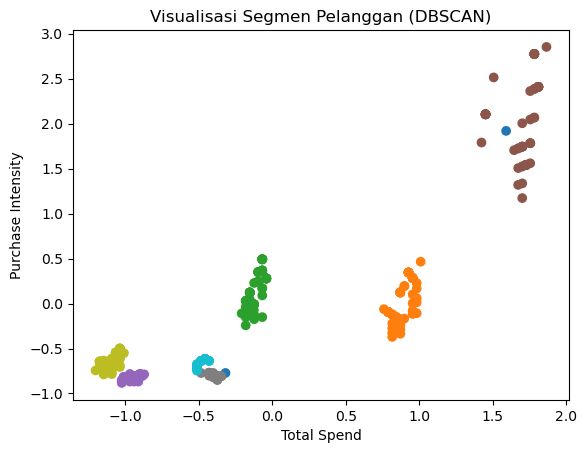

In [70]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
Cluster_DBSCAN = dbscan.fit_predict(df[kolom_nomor])

df['Cluster_DBSCAN'] = dbscan.labels_
print(df['Cluster_DBSCAN'].value_counts())

plt.scatter(df['Total Spend'], df['Purchase_Intensity'], c=df['Cluster_DBSCAN'], cmap='tab10')
plt.xlabel('Total Spend')
plt.ylabel('Purchase Intensity')
plt.title('Visualisasi Segmen Pelanggan (DBSCAN)')
plt.show()

Subtask 2: UNSUPERVISED LEARNING
(3)Analisis Kritis

In [73]:
le = LabelEncoder()
df['Satisfaction_Level_Num'] = le.fit_transform(df['Satisfaction Level'])

X = df[['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 
        'Days Since Last Purchase', 'Purchase_Intensity', 'Cluster']]
y = df['Satisfaction_Level_Num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)
akurasi = model_rf.score(X_test, y_test)

print("=== EVALUASI MODEL RANDOM FOREST ===")
print(f"Akurasi: {model_rf.score(X_test, y_test):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

=== EVALUASI MODEL RANDOM FOREST ===
Akurasi: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        29
           2       1.00      1.00      1.00        18

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70


Confusion Matrix:
[[23  0  0]
 [ 0 29  0]
 [ 0  0 18]]
